# Intelligent Financial Fraud Detection
### NTU Datathon 2026 · Track 2 (Finance) · Team **The Larpers**

**Goal:** flag fraudulent transactions while disrupting as few legitimate customers as possible.

**Executive summary**
- **Framing:** only 1.8% of transactions are fraud, so accuracy is meaningless. We optimise the **risk ranking** (PR-AUC), then choose a **cost-aware decision threshold**.
- **What drives fraud:** new devices, young accounts, bursts of activity, and mid-to-large tickets in cash transfer, electronics and luxury. The riskiest combination (account < 90 days **and** ≥ 4 transactions in an hour) is **~40% fraud**, versus 1.8% overall.
- **The test set is a shifted population:** it has 3× more missing values and 3× more high-velocity transactions. We therefore engineered for **robustness**, not for the leaderboard.
- **Model:** 5 seed-bagged gradient-boosting models (pure scikit-learn) with **monotonic constraints** from domain knowledge, trained with **missing-value augmentation**. The decision threshold lives inside `model.pkl`.
- **Results (out-of-fold, 3× repeated 5-fold CV):**
  - Ranking quality: **PR-AUC ≈ 0.206 ± 0.003** (≈ 12× random), ROC-AUC ≈ 0.77.
  - At the chosen threshold (≈ 0.095, i.e. "a missed fraud costs ~10× a false alarm"), the model flags **~1.7% of transactions**.
  - Those alerts catch **~27% of frauds and ~46% of fraud dollars**, and **1 in 3.7 alerts is real fraud** (precision ≈ recall ≈ F1 ≈ 0.27).
- **Robustness:** the model is unit-tested on messy inputs (text in numeric fields, ±inf, negatives, unseen categories, missing columns). Missing-value augmentation adds about +0.009 PR-AUC on clean *and* on gappy data.

**Notebook map:** 1 Problem → 2 Data audit → 3 EDA → 4 Train-vs-test shift → 5 Feature engineering → 6 Validation design → 7 Model comparison → 8 Final model → 9 Decision threshold → 10 Final evaluation → 11 Explainability → 12 Robustness → 13 Save model & predict

> **How to run:** put `Track 2 Training Dataset.csv` and `Track 2 Testing Dataset.csv` next to this notebook (in Colab, upload them to the Files panel), then *Run all*. Runtime is about 7 minutes on a standard Colab CPU. Uses only numpy, pandas, scikit-learn (≥ 1.5), joblib and matplotlib.

In [1]:
import os, glob, sys, time, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import sklearn
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split, FixedThresholdClassifier  # needs scikit-learn >= 1.5
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve, precision_score,
                             recall_score, f1_score, fbeta_score, confusion_matrix)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
TEAM_NAME = 'The Larpers'
T0 = time.time()

# Chart style: colour-blind-safe palette, light grid, no chart junk
BLUE, ORANGE, AQUA, YELLOW, VIOLET = '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#4a3aa7'
INK, INK2, MUTED, GRID = '#0b0b0b', '#52514e', '#898781', '#e1e0d9'
SEQ = LinearSegmentedColormap.from_list('seq_blue', ['#cde2fb', '#86b6ef', '#3987e5', '#1c5cab', '#0d366b'])
plt.rcParams.update({'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb', 'axes.edgecolor': '#c3c2b7',
                     'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2, 'axes.grid': True,
                     'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.axisbelow': True,
                     'axes.spines.top': False, 'axes.spines.right': False, 'axes.titleweight': 'bold',
                     'axes.titlesize': 10.5, 'axes.titlecolor': INK, 'font.size': 9, 'legend.frameon': False})

print(f'python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | pandas {pd.__version__} | numpy {np.__version__}')

python 3.13.16 | scikit-learn 1.6.1 | pandas 2.2.3 | numpy 2.1.3


## 1. Understanding the problem

- **The task:** a supervised binary classification. Each row is one card or app transaction, and `fraud = 1` marks the fraudulent ones.
- **The data is extremely imbalanced:** fewer than 2 in 100 transactions are fraud. A model that always answers "legit" is 98% accurate and completely useless, so **accuracy is not used anywhere in this notebook**.
- **The business trade-off:**
  - A **missed fraud (false negative)** costs the bank the stolen amount, plus chargeback fees and loss of trust.
  - A **false alarm (false positive)** costs a blocked or challenged legitimate customer: friction, support calls and possible churn.
- **How we measure success** (the competition's metrics):
  - **PR-AUC (average precision):** how well the model *ranks* risky transactions above safe ones. It is threshold-free, and a random guess scores the fraud rate (≈ 0.018).
  - **Recall:** the share of all frauds we catch.
  - **F1:** the balance between catching fraud (recall) and not bothering good customers (precision).
- **A two-step design that follows from this:**
  1. Build the best possible **risk score**, a probability judged by PR-AUC.
  2. Choose the **decision threshold** that turns scores into actions, based on the cost of each type of error (section 9).

In [2]:
def find_csv(default_name, pattern, env_var=None):
    # Locate a data file: environment variable -> file next to the notebook -> common data folders
    if env_var and os.environ.get(env_var):
        return os.environ[env_var]
    if os.path.exists(default_name):
        return default_name
    for root in ['.', '/content', 'data', '/kaggle/input']:
        for depth in ['', '*', os.path.join('*', '*')]:
            hits = sorted(glob.glob(os.path.join(root, depth, pattern)))
            if hits:
                return hits[0]
    raise FileNotFoundError(f'{default_name} not found - upload it next to this notebook.')

TRAIN_PATH = find_csv('Track 2 Training Dataset.csv', '*Train*.csv', 'DATATHON_TRAIN_PATH')
TEST_PATH = find_csv('Track 2 Testing Dataset.csv', '*Test*.csv', 'DATATHON_INPUT_PATH')
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
TARGET = 'fraud'
y = train_df[TARGET].values
print(f'Train: {train_df.shape} from {TRAIN_PATH}\nTest:  {test_df.shape} from {TEST_PATH}')
train_df.head()

Train: (20000, 12) from Track 2 Training Dataset.csv
Test:  (12000, 11) from Track 2 Testing Dataset.csv


,id,transaction_amount,transaction_hour,merchant_category,country,transaction_channel,transactions_last_24h,spend_last_24h,account_age,new_device,transactions_last_1h,fraud
0,FR016993,55.03,16,retail,SG,ecommerce,27.0,1791.34,1192.0,0.0,5.0,0
1,FR002433,20.75,1,gaming,SG,mobile_app,3.0,217.96,3073.0,0.0,0.0,0
2,FR009253,21.51,9,entertainment,SG,mobile_app,3.0,62.71,985.0,0.0,0.0,0
3,FR004881,813.98,16,utilities,GB,mobile_app,2.0,110.48,653.0,0.0,1.0,0
4,FR014830,13.54,20,food_delivery,SG,card_present,4.0,114.98,79.0,0.0,0.0,0


## 2. Data audit: what are we working with?

In [3]:
RAW_NUM = ['transaction_amount', 'transaction_hour', 'transactions_last_24h', 'spend_last_24h',
           'account_age', 'new_device', 'transactions_last_1h']
CAT = ['merchant_category', 'country', 'transaction_channel']

audit = pd.DataFrame({'dtype': train_df.dtypes.astype(str),
                      'unique values': train_df.nunique(),
                      'missing % (train)': (100 * train_df.isna().mean()).round(2),
                      'missing % (test)': (100 * test_df.isna().mean()).round(2).reindex(train_df.columns)})
display(audit)

ids = train_df['id'].str[2:].astype(int)
checks = pd.Series({
    'duplicate ids': train_df['id'].duplicated().sum(),
    'duplicate transactions (ignoring id)': train_df.drop(columns='id').duplicated().sum(),
    'ids shared by train and test': len(set(train_df['id']) & set(test_df['id'])),
    'transactions_last_1h > transactions_last_24h': (train_df.transactions_last_1h > train_df.transactions_last_24h).sum(),
    'negative amounts / hours outside 0-23': f"{(train_df.transaction_amount < 0).sum()} / {(~train_df.transaction_hour.between(0, 23)).sum()}",
    'rows with >= 1 missing field (train / test)': f"{train_df.drop(columns=TARGET).isna().any(axis=1).mean():.1%} / {test_df.isna().any(axis=1).mean():.1%}",
})
print(checks.to_string())
print('\nFraud rate by id decile:', (100 * train_df.groupby(pd.qcut(ids, 10), observed=True)[TARGET].mean()).round(1).tolist())

,dtype,unique values,missing % (train),missing % (test)
id,object,20000,0.00,0.00
transaction_amount,float64,14134,0.00,0.00
transaction_hour,int64,24,0.00,0.00
merchant_category,object,11,0.56,2.16
country,object,10,0.53,2.23
transaction_channel,object,4,0.62,2.37
transactions_last_24h,float64,27,0.80,2.44
spend_last_24h,float64,16987,0.66,2.22
account_age,float64,3366,0.68,2.20
new_device,float64,2,0.62,2.44


duplicate ids                                              0
duplicate transactions (ignoring id)                       0
ids shared by train and test                               0
transactions_last_1h > transactions_last_24h               0
negative amounts / hours outside 0-23                  0 / 0
rows with >= 1 missing field (train / test)     4.9% / 13.9%

Fraud rate by id decile: [1.8, 1.6, 2.0, 1.6, 1.5, 1.7, 2.0, 2.1, 1.9, 1.6]


**Audit findings:**
- **Clean structure:** there are no duplicates and no train/test id overlap, and the fields are logically consistent (1-hour activity never exceeds 24-hour activity).
- **`id` carries no signal:** it is a sequential counter (train 1–20,000, test 20,001–32,000), and the fraud rate is flat across its deciles, so it hides no time trend or leakage. **We drop it.**
- **Missing values are scattered:** about 0.6% per field in train, but **about 2.3% per field in test**. Roughly 14% of test rows have a gap, versus 5% in train, so robust handling of missing data matters (sections 8 and 12).

## 3. Exploratory data analysis: what does fraud look like?

Fraud rate: 1.76%  (353 frauds out of 20,000 transactions)
"Always legit" model: 98.2% accuracy, 0% of frauds caught  ->  accuracy is the wrong metric
Random-guess PR-AUC = fraud rate = 0.018  ->  the bar every model must clear


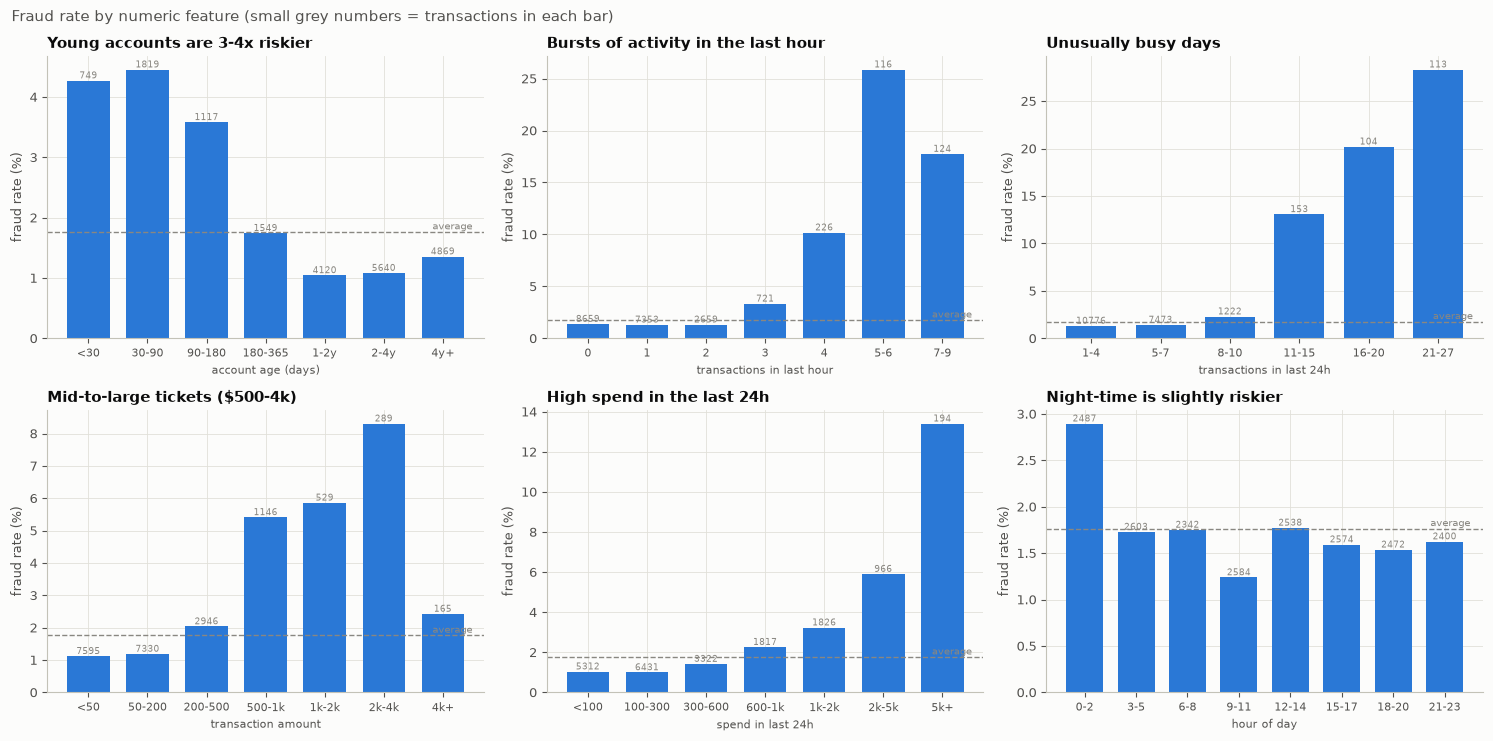

In [4]:
rate = y.mean()
print(f'Fraud rate: {rate:.2%}  ({y.sum()} frauds out of {len(y):,} transactions)')
print(f'"Always legit" model: {1 - rate:.1%} accuracy, 0% of frauds caught  ->  accuracy is the wrong metric')
print(f'Random-guess PR-AUC = fraud rate = {rate:.3f}  ->  the bar every model must clear')

def risk_bars(ax, values, bins, labels, title, xlabel=''):
    grp = train_df.groupby(pd.cut(values, bins, labels=labels, include_lowest=True), observed=False)[TARGET].agg(['mean', 'size'])
    x = np.arange(len(grp))
    ax.bar(x, 100 * grp['mean'].fillna(0), color=BLUE, width=0.72)
    ax.axhline(100 * rate, ls='--', lw=1, color=MUTED)
    ax.text(len(grp) - 0.5, 100 * rate, 'average', color=MUTED, fontsize=7.5, ha='right', va='bottom')
    ax.set_xticks(x, grp.index.astype(str), fontsize=8)
    ax.set_title(title, loc='left'); ax.set_ylabel('fraud rate (%)'); ax.set_xlabel(xlabel, fontsize=8)
    for xi, (m, n) in zip(x, grp.values):
        ax.text(xi, 100 * (0 if np.isnan(m) else m), f'{int(n)}', ha='center', va='bottom', fontsize=6.5, color=MUTED)

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
risk_bars(axes[0, 0], train_df.account_age, [0, 30, 90, 180, 365, 730, 1500, 5000],
          ['<30', '30-90', '90-180', '180-365', '1-2y', '2-4y', '4y+'], 'Young accounts are 3-4x riskier', 'account age (days)')
risk_bars(axes[0, 1], train_df.transactions_last_1h, [-1, 0, 1, 2, 3, 4, 6, 9],
          ['0', '1', '2', '3', '4', '5-6', '7-9'], 'Bursts of activity in the last hour', 'transactions in last hour')
risk_bars(axes[0, 2], train_df.transactions_last_24h, [0, 4, 7, 10, 15, 20, 27],
          ['1-4', '5-7', '8-10', '11-15', '16-20', '21-27'], 'Unusually busy days', 'transactions in last 24h')
risk_bars(axes[1, 0], train_df.transaction_amount, [0, 50, 200, 500, 1000, 2000, 4000, 1e6],
          ['<50', '50-200', '200-500', '500-1k', '1k-2k', '2k-4k', '4k+'], 'Mid-to-large tickets ($500-4k)', 'transaction amount')
risk_bars(axes[1, 1], train_df.spend_last_24h, [-1, 100, 300, 600, 1000, 2000, 5000, 1e6],
          ['<100', '100-300', '300-600', '600-1k', '1k-2k', '2k-5k', '5k+'], 'High spend in the last 24h', 'spend in last 24h')
risk_bars(axes[1, 2], train_df.transaction_hour, [-1, 2, 5, 8, 11, 14, 17, 20, 23],
          ['0-2', '3-5', '6-8', '9-11', '12-14', '15-17', '18-20', '21-23'], 'Night-time is slightly riskier', 'hour of day')
fig.suptitle('Fraud rate by numeric feature (small grey numbers = transactions in each bar)', x=0.01, ha='left', fontsize=11, color=INK2)
plt.tight_layout(); plt.show()

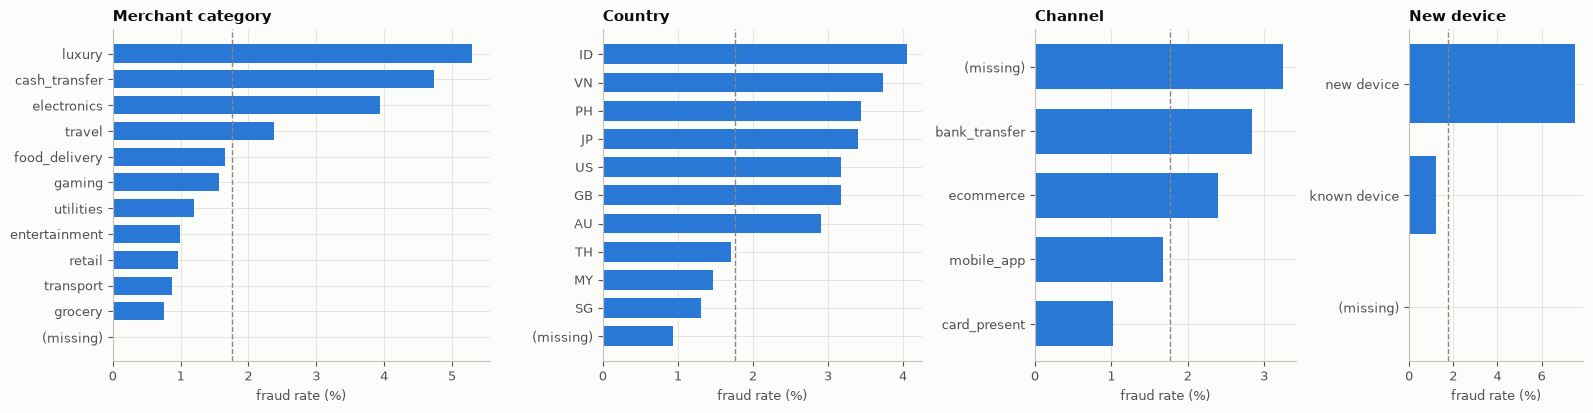

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), gridspec_kw={'width_ratios': [1.3, 1.1, 0.9, 0.6]})
for ax, col, title in zip(axes, ['merchant_category', 'country', 'transaction_channel', 'new_device'],
                          ['Merchant category', 'Country', 'Channel', 'New device']):
    labels = train_df[col].map({0: 'known device', 1: 'new device'}) if col == 'new_device' else train_df[col]
    g = train_df.groupby(labels.fillna('(missing)'), observed=True)[TARGET].mean().sort_values()
    ax.barh(g.index, 100 * g.values, color=BLUE, height=0.7)
    ax.axvline(100 * rate, ls='--', lw=1, color=MUTED)
    ax.set_title(title, loc='left'); ax.set_xlabel('fraud rate (%)')
plt.tight_layout(); plt.show()

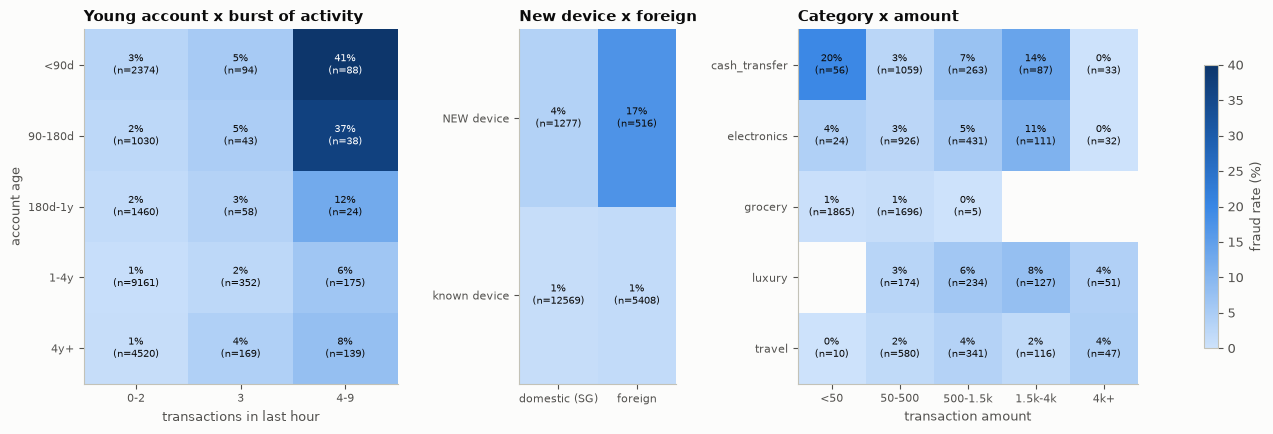

In [6]:
def heat(ax, data, title, xlabel, ylabel):
    rates = data.pivot_table(index='r', columns='c', values=TARGET, aggfunc='mean', observed=False)
    counts = data.pivot_table(index='r', columns='c', values=TARGET, aggfunc='size', observed=False)
    im = ax.imshow(100 * rates.values, cmap=SEQ, aspect='auto', vmin=0, vmax=40)
    for i in range(rates.shape[0]):
        for j in range(rates.shape[1]):
            v, n = rates.values[i, j], counts.values[i, j]
            if n > 0 and not np.isnan(v):
                ax.text(j, i, f'{100 * v:.0f}%\n(n={int(n)})', ha='center', va='center', fontsize=7,
                        color='white' if 100 * v > 20 else INK)
    ax.set_xticks(range(rates.shape[1]), rates.columns.astype(str), fontsize=8)
    ax.set_yticks(range(rates.shape[0]), rates.index.astype(str), fontsize=8)
    ax.set_title(title, loc='left'); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.grid(False)
    return im

d = train_df.copy()
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), gridspec_kw={'width_ratios': [1.2, 0.6, 1.3], 'wspace': 0.45})
heat(axes[0], d.assign(r=pd.cut(d.account_age, [0, 90, 180, 365, 1500, 5000], labels=['<90d', '90-180d', '180d-1y', '1-4y', '4y+']),
                       c=pd.cut(d.transactions_last_1h, [-1, 2, 3, 9], labels=['0-2', '3', '4-9'])),
     'Young account x burst of activity', 'transactions in last hour', 'account age')
dn = d[d.country.notna() & d.new_device.notna()]
heat(axes[1], dn.assign(r=dn.new_device.map({0: 'known device', 1: 'NEW device'}),
                        c=np.where(dn.country == 'SG', 'domestic (SG)', 'foreign')),
     'New device x foreign', '', '')
top = ['cash_transfer', 'electronics', 'luxury', 'travel', 'grocery']
dd = d[d.merchant_category.isin(top)]
im = heat(axes[2], dd.assign(r=dd.merchant_category,
                             c=pd.cut(dd.transaction_amount, [0, 50, 500, 1500, 4000, 1e6], labels=['<50', '50-500', '500-1.5k', '1.5k-4k', '4k+'])),
          'Category x amount', 'transaction amount', '')
fig.colorbar(im, ax=axes, shrink=0.8, label='fraud rate (%)')
plt.show()

**What fraud looks like.** Each row in the table is a pattern we will want the model to capture.

| Fraud pattern | Evidence | Fraud rate |
|---|---|---|
| **Account takeover / mule accounts**: a young account suddenly bursts with transactions | account < 90 days **and** ≥ 4 transactions in the last hour | **~40%** (vs 1.8% overall) |
| **New device**, especially from abroad | new device: 7.5% · new device **and** foreign: **~17%** | 4–10× |
| **High-velocity days** | > 10 transactions in 24h | 13–28% |
| **Mid/large tickets in "liquid" categories** (cash transfer, electronics, luxury) | $1.5k–4k cash transfers ≈ 14% · electronics ≈ 11% | 6–8× |

Three things the model must get right:
1. **The signal lives in interactions.** High velocity on an *old* account is mostly a legitimate power user (fraud ≈ 6–8%). The same velocity on a *young* account is ≈ 40% fraud. This calls for tree-based models.
2. **Very large amounts (> $4k) are *less* risky than $1.5k–4k.** Train has no fraud above $4k in cash transfers or electronics. So "bigger amount → more fraud" is **not** a safe rule, and we do **not** force amount to be monotonic.
3. **Even the riskiest segments are < 50% fraud.** The labels are inherently noisy: no model can be near-perfect here. Realistic targets are a PR-AUC around 0.2 (≈ 12× random) and an F1 around 0.3.

In [7]:
def adv_frame(df):
    X_ = df.reindex(columns=RAW_NUM).apply(pd.to_numeric, errors='coerce')
    for c in CAT:
        X_[c] = df[c].fillna('missing').astype(str)
    X_['n_missing'] = df.reindex(columns=RAW_NUM + CAT).isna().sum(axis=1)
    return X_

A = pd.concat([adv_frame(train_df), adv_frame(test_df)], ignore_index=True)
is_test = np.r_[np.zeros(len(train_df)), np.ones(len(test_df))]
adv_model = Pipeline([('pre', ColumnTransformer([('num', 'passthrough', RAW_NUM + ['n_missing']),
                                                 ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT)])),
                      ('clf', HistGradientBoostingClassifier(max_depth=4, max_iter=200, learning_rate=0.05, random_state=SEED))])
adv_p = cross_val_predict(adv_model, A, is_test, cv=StratifiedKFold(5, shuffle=True, random_state=SEED), method='predict_proba')[:, 1]
print(f'Adversarial validation: ROC-AUC for telling train from test = {roc_auc_score(is_test, adv_p):.3f}  (0.5 would mean identical populations)')

def profile(df):
    return pd.Series({'rows with a missing field (%)': 100 * df.reindex(columns=RAW_NUM + CAT).isna().any(axis=1).mean(),
                      'new device (%)': 100 * (df.new_device == 1).mean(),
                      '>= 5 transactions in last hour (%)': 100 * (df.transactions_last_1h >= 5).mean(),
                      'amount > 1,500 (%)': 100 * (df.transaction_amount > 1500).mean(),
                      'amount > 4,000 (%)': 100 * (df.transaction_amount > 4000).mean(),
                      'median account age (days)': df.account_age.median()})
shift = pd.DataFrame({'train': profile(train_df), 'test': profile(test_df)})
shift['test / train'] = shift['test'] / shift['train']
display(shift.round(2))

q = pd.qcut(adv_p[:len(train_df)], 5, labels=['1 (least test-like)', '2', '3', '4', '5 (most test-like)'])
print('Fraud rate of TRAIN rows by how "test-like" they look:')
print((100 * train_df.groupby(q, observed=True)[TARGET].mean()).round(2).to_string())

Adversarial validation: ROC-AUC for telling train from test = 0.668  (0.5 would mean identical populations)


,train,test,test / train
rows with a missing field (%),4.88,13.86,2.84
new device (%),9.00,14.99,1.67
>= 5 transactions in last hour (%),1.20,3.49,2.91
"amount > 1,500 (%)",3.10,10.84,3.49
"amount > 4,000 (%)",0.82,3.99,4.84
median account age (days),790.00,1158.00,1.47


Fraud rate of TRAIN rows by how "test-like" they look:
1 (least test-like)    1.23
2                      1.55
3                      1.12
4                      1.88
5 (most test-like)     3.05


## 4. Train vs test: the population has shifted

The test set is **not** a random copy of the training set:
- An adversarial classifier can tell the two apart (ROC-AUC ≈ 0.67).
- The test set has:
  - **3× more missing values**,
  - **~3× more high-velocity transactions**,
  - more new devices,
  - a much heavier tail of large amounts,
  - older accounts.
- Training rows that look most like the test set have **about twice the fraud rate**.

The private test set "may contain different observations and edge cases", so we design for robustness, not for the public leaderboard:

| Risk | What we do |
|---|---|
| More missing values | Gradient boosting handles missing values natively, **plus** we train on a copy of the data with randomly blanked fields (section 8) |
| Rare, extreme behaviour (bursts of 7–9 transactions/hour) learnt from only ~100 rows | **Monotonic constraints** encode domain knowledge: more velocity or a new device can never *lower* risk (section 8) |
| Messy inputs (text in numeric columns, unseen categories, missing columns) | `make_features` cleans everything defensively and is unit-tested on garbage rows (section 12) |
| Over-tuning to noise | Repeated cross-validation, shallow regularised trees, and no tuning on the public leaderboard |

## 5. Feature engineering

**Design principles:**
- **One self-contained function** (`make_features`) is used identically for training, validation, the test set and the hidden private set, so there is no train/serve skew.
- **Defensive by construction:**
  - numeric fields are coerced (text becomes missing, ±inf becomes missing, negatives are clipped);
  - categories are normalised (`' Retail'` → `'retail'`) and unseen categories are tolerated;
  - columns that are absent are created as missing.
- **Few, interpretable features**, each tied to a fraud mechanism from the EDA. We tested 17 engineered features. With tree models most added no measurable lift, so we kept the 7 that are meaningful and robust.

In [8]:
# ==== FEATURE ENGINEERING - self-contained cell (copy it together with the inference cell in section 13) ====
import numpy as np
import pandas as pd

RAW_NUM = ['transaction_amount', 'transaction_hour', 'transactions_last_24h', 'spend_last_24h',
           'account_age', 'new_device', 'transactions_last_1h']
CAT = ['merchant_category', 'country', 'transaction_channel']
# Median transaction amount per merchant category, measured once on the TRAINING data (frozen constants)
CAT_MEDIAN_AMOUNT = {'cash_transfer': 261.7, 'electronics': 375.7, 'entertainment': 64.6, 'food_delivery': 29.8,
                     'gaming': 38.5, 'grocery': 47.6, 'luxury': 846.6, 'retail': 120.5, 'transport': 23.9,
                     'travel': 443.8, 'utilities': 110.9}
ENGINEERED = ['amount_vs_avg_ticket', 'amount_vs_category', 'burst_ratio', 'night', 'foreign', 'young_account', 'n_missing']
FEATURES = RAW_NUM + ENGINEERED + CAT

def make_features(df):
    # Turn raw transactions into model features. Robust to messy inputs: missing/extra columns,
    # text in numeric fields, +-inf, negative values, unseen or differently-written categories.
    df = df.copy()
    for c in RAW_NUM:
        if c not in df.columns:
            df[c] = np.nan
        df[c] = pd.to_numeric(df[c], errors='coerce').replace([np.inf, -np.inf], np.nan)
    for c in CAT:
        if c not in df.columns:
            df[c] = np.nan
        df[c] = df[c].astype('string').str.strip().str.lower().replace('', pd.NA).fillna('missing')
    amount = df['transaction_amount'].clip(lower=0)
    spend = df['spend_last_24h'].clip(lower=0)
    tx_24h = df['transactions_last_24h'].clip(lower=0)
    tx_1h = df['transactions_last_1h'].clip(lower=0)
    age = df['account_age'].clip(lower=0)
    # 1) Behavioural deviation: is this payment unusually large for THIS customer / for THIS merchant type?
    df['amount_vs_avg_ticket'] = np.log1p(amount) - np.log1p(spend / (tx_24h + 1))
    df['amount_vs_category'] = np.log1p(amount) - np.log1p(df['merchant_category'].map(CAT_MEDIAN_AMOUNT).astype(float))
    # 2) Velocity: share of the day's activity squeezed into the last hour (bots / account takeover)
    df['burst_ratio'] = tx_1h / (tx_24h + 1)
    # 3) Context flags
    df['night'] = df['transaction_hour'].isin([23, 0, 1, 2, 3, 4]).astype(float).where(df['transaction_hour'].notna())
    df['foreign'] = (df['country'] != 'sg').astype(float).where(df['country'] != 'missing')
    df['young_account'] = (age < 180).astype(float).where(age.notna())
    # 4) Data-quality signal: how many fields are missing on this transaction
    df['n_missing'] = df[RAW_NUM].isna().sum(axis=1) + (df[CAT] == 'missing').sum(axis=1)
    num_cols = df.select_dtypes('number').columns
    df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
    return df

In [9]:
# sanity check: the frozen category medians match the training data
med = train_df.groupby('merchant_category')['transaction_amount'].median()
assert all(abs(med[k] - v) < 0.1 for k, v in CAT_MEDIAN_AMOUNT.items()), 'category medians out of date'

X = make_features(train_df)
X_test = make_features(test_df)
print('Feature matrix:', X[FEATURES].shape, '| test:', X_test[FEATURES].shape)

signal = pd.DataFrame({
    'meaning': ['payment vs customer\'s average ticket (log ratio)', 'payment vs typical amount for the category (log ratio)',
                'share of 24h activity in the last hour', 'between 23:00 and 04:59', 'country is not Singapore',
                'account younger than 180 days', 'number of missing fields'],
    'ROC-AUC on its own': [roc_auc_score(y, X[f].fillna(X[f].median())) for f in ENGINEERED],
    'mean (fraud)': [X.loc[y == 1, f].mean() for f in ENGINEERED],
    'mean (legit)': [X.loc[y == 0, f].mean() for f in ENGINEERED]}, index=ENGINEERED)
signal.round(3)

Feature matrix: (20000, 17) | test: (12000, 17)


,meaning,ROC-AUC on its own,mean (fraud),mean (legit)
amount_vs_avg_ticket,payment vs customer's average ticket (log ratio),0.550,0.813,0.686
amount_vs_category,payment vs typical amount for the category (lo...,0.577,0.271,0.025
burst_ratio,share of 24h activity in the last hour,0.570,0.188,0.144
night,between 23:00 and 04:59,0.566,0.382,0.250
foreign,country is not Singapore,0.593,0.483,0.296
young_account,account younger than 180 days,0.627,0.437,0.181
n_missing,number of missing fields,0.504,0.059,0.052


## 6. Validation design

- **How we test:** **repeated stratified 5-fold cross-validation**. Every transaction is scored by a model that never saw it during training (*out-of-fold* predictions). Stratification keeps about 70 frauds in every fold.
- **Noise level:** with only 353 frauds, PR-AUC moves by about ±0.006 between CV repeats. So **differences smaller than about 0.01 are noise**.
- **Lesson from tuning:** our hyper-parameter search showed this clearly. The best of 40 configurations scored 0.215 on a 2-repeat CV, then **fell to 0.206 when re-validated** with 4 repeats (the *winner's curse*). We therefore prefer simple, robust choices over chasing the third decimal.
- **The test set is never used for any decision.** We only look at its *features*, to understand the population shift (section 4).

In [10]:
GAPPY_FIELDS = ['transactions_last_24h', 'spend_last_24h', 'account_age', 'new_device', 'transactions_last_1h'] + CAT

def blank_fields(df_raw, rate=0.03, seed=0):
    # Randomly blank out ~rate of each field that can be missing (mimics the gappier test data)
    rng = np.random.default_rng(seed)
    noisy = df_raw.copy()
    for c in GAPPY_FIELDS:
        noisy.loc[rng.random(len(noisy)) < rate, c] = np.nan
    return noisy

def augment_with_missing(df_raw, rate=0.03, seed=0):
    # Robustness training: original rows + a copy with randomly blanked fields
    return pd.concat([df_raw, blank_fields(df_raw, rate, seed)], ignore_index=True)

def fit_on_raw(model, df_raw, augment=False, seed=0):
    if augment:
        df_raw = augment_with_missing(df_raw, seed=seed)
    return clone(model).fit(make_features(df_raw)[FEATURES], df_raw[TARGET].values)

def cv_oof(model, n_repeats=1, augment=False, keep_models=None):
    # Out-of-fold fraud probabilities from repeated stratified 5-fold CV -> array (n_repeats, n_rows)
    # keep_models: optional list that receives (validation_index, fitted_model) for the first repeat
    oofs = []
    for r in range(n_repeats):
        oof = np.zeros(len(train_df))
        for k, (trn, val) in enumerate(StratifiedKFold(5, shuffle=True, random_state=100 + r).split(train_df, y)):
            fitted = fit_on_raw(model, train_df.iloc[trn], augment, seed=10 * r + k)
            oof[val] = fitted.predict_proba(X.iloc[val][FEATURES])[:, 1]
            if keep_models is not None and r == 0:
                keep_models.append((val, fitted))
        oofs.append(oof)
    return np.array(oofs)

def best_threshold(y_true, p, beta=1.5):
    # threshold maximising the F-beta score on one set of out-of-fold scores
    pr, rc, th = precision_recall_curve(y_true, p)
    f = (1 + beta ** 2) * pr * rc / (beta ** 2 * pr + rc + 1e-12)
    return th[np.argmax(f[:-1])]

def best_f1(y_true, p):
    pr, rc, _ = precision_recall_curve(y_true, p)
    return np.max(2 * pr * rc / (pr + rc + 1e-12))

def summarize(name, oofs, seconds):
    return {'model': name,
            'PR-AUC': np.mean([average_precision_score(y, o) for o in oofs]),
            'ROC-AUC': np.mean([roc_auc_score(y, o) for o in oofs]),
            'best achievable F1': np.mean([best_f1(y, o) for o in oofs]),
            'train+predict time (s)': round(seconds, 1)}

## 7. Baseline and model comparison

We start from a transparent **baseline** (logistic regression) and then try increasingly flexible models, all on the **same folds**:
- **Random forest**
- **Gradient boosting** (scikit-learn's `HistGradientBoostingClassifier`): first with default settings, then tuned, then tuned **plus monotonic constraints**
- **LightGBM** and **XGBoost**, as external benchmarks if they are installed

Tuned settings come from a random search over 40 configurations: learning rate, depth, leaves, minimum leaf size, L2 penalty, feature subsampling and class weights. What the search taught us:
- **Shallow trees** (depth ≤ 4, 8 leaves) with **large leaves** (≥ 80 transactions) and **many small steps** (learning rate 0.01) work best. Deeper or faster models memorise noise.
- **`class_weight='balanced'` consistently *hurt* PR-AUC** (by −0.01 to −0.04). Re-weighting 353 frauds distorts the probabilities. We fix the imbalance at the *decision threshold* instead (section 9).

In [11]:
def one_hot():
    return OneHotEncoder(handle_unknown='ignore', sparse_output=False, min_frequency=20)

def tree_preprocessor():
    return ColumnTransformer([('num', 'passthrough', RAW_NUM + ENGINEERED), ('cat', one_hot(), CAT)]).set_output(transform='pandas')

logreg = Pipeline([('pre', ColumnTransformer([('num', Pipeline([('impute', SimpleImputer(strategy='median', add_indicator=True)),
                                                                ('scale', StandardScaler())]), RAW_NUM + ENGINEERED),
                                              ('cat', OneHotEncoder(handle_unknown='ignore'), CAT)])),
                   ('clf', LogisticRegression(C=0.3, class_weight='balanced', max_iter=5000))])
forest = Pipeline([('pre', ColumnTransformer([('num', SimpleImputer(strategy='median', add_indicator=True), RAW_NUM + ENGINEERED),
                                              ('cat', one_hot(), CAT)])),
                   ('clf', RandomForestClassifier(n_estimators=300, min_samples_leaf=30, max_features=0.3, n_jobs=-1, random_state=SEED))])
hgb_default = Pipeline([('pre', tree_preprocessor()), ('clf', HistGradientBoostingClassifier(random_state=SEED))])

TUNED = dict(learning_rate=0.01, max_iter=800, max_depth=4, max_leaf_nodes=8, min_samples_leaf=80,
             l2_regularization=0.0, max_features=0.5)
# Domain knowledge: holding everything else fixed, risk can only go UP with a new device or more activity,
# and only DOWN as the account gets older. (Amount is deliberately left free - see EDA.)
MONOTONIC = {'num__new_device': 1, 'num__transactions_last_1h': 1, 'num__transactions_last_24h': 1,
             'num__spend_last_24h': 1, 'num__account_age': -1}

def hgb(seed=SEED, monotonic=False):
    return Pipeline([('pre', tree_preprocessor()),
                     ('clf', HistGradientBoostingClassifier(**TUNED, random_state=seed,
                                                            monotonic_cst=MONOTONIC if monotonic else None))])

candidates = [('Logistic regression (baseline)', logreg),
              ('Random forest', forest),
              ('Gradient boosting - default', hgb_default),
              ('Gradient boosting - tuned', hgb()),
              ('Gradient boosting - tuned + monotonic', hgb(monotonic=True))]
try:
    from lightgbm import LGBMClassifier
    candidates.append(('LightGBM - tuned (benchmark)', Pipeline([('pre', tree_preprocessor()), ('clf', LGBMClassifier(
        n_estimators=600, learning_rate=0.01, num_leaves=8, max_depth=4, min_child_samples=80, subsample=0.8,
        subsample_freq=1, colsample_bytree=0.5, verbose=-1, random_state=SEED))])))
except ImportError:
    print('LightGBM not installed - skipped')
try:
    from xgboost import XGBClassifier
    candidates.append(('XGBoost - tuned (benchmark)', Pipeline([('pre', tree_preprocessor()), ('clf', XGBClassifier(
        n_estimators=600, learning_rate=0.01, max_depth=3, min_child_weight=5, subsample=0.8, colsample_bytree=0.5,
        reg_lambda=5, eval_metric='aucpr', random_state=SEED))])))
except ImportError:
    print('XGBoost not installed - skipped')

results, OOF = [], {}
for name, model in candidates:
    t = time.time()
    OOF[name] = cv_oof(model, n_repeats=1)
    results.append(summarize(name, OOF[name], time.time() - t))
    print(f'{name:42s} PR-AUC {results[-1]["PR-AUC"]:.4f}')

Logistic regression (baseline)             PR-AUC 0.1943


Random forest                              PR-AUC 0.1884


Gradient boosting - default                PR-AUC 0.1645


Gradient boosting - tuned                  PR-AUC 0.2083


Gradient boosting - tuned + monotonic      PR-AUC 0.1988


LightGBM - tuned (benchmark)               PR-AUC 0.2093


XGBoost - tuned (benchmark)                PR-AUC 0.2003


## 8. Final model: robust gradient boosting

Our final model is **5 monotonic gradient-boosting models with different random seeds, averaged together**, trained on the data **plus a copy with randomly blanked fields**. It is pure scikit-learn and needs no extra dependencies.

| Design choice | Why |
|---|---|
| **Gradient boosting** (shallow, regularised) | It captures the interactions found in the EDA (young account × burst, new device × foreign), handles missing values natively, ignores feature scaling and outliers, and gave the best PR-AUC |
| **Monotonic constraints** (new device ↑, activity ↑, spend ↑, account age ↓) | They encode domain knowledge as a hard guarantee. The test set has 3× more extreme-velocity transactions than train, and the constraints stop the model from learning noisy dips such as "9 transactions/hour is safer than 6". The cost is about −0.004 PR-AUC in repeated CV, which is well inside the noise band |
| **Bagging over 5 seeds** (`max_features=0.5`, so each model sees different feature subsets) | It averages out the variance of a model trained on only 353 frauds, giving stabler scores across CV repeats |
| **Missing-value augmentation** (a training copy with 3% of each field blanked) | The test set has 3× more gaps. The model learns how to score incomplete transactions instead of guessing (stress test in section 12) |

We evaluate it with **3 repeats** of 5-fold CV. The first repeat uses the same folds as the comparison above.

Final model over 3 CV repeats: PR-AUC 0.2062 +/- 0.0033  |  ROC-AUC 0.7711


,PR-AUC,x random,ROC-AUC,best achievable F1,train+predict time (s)
model,,,,,
Logistic regression (baseline),0.1943,11.0070,0.7693,0.2779,3.0
Random forest,0.1884,10.6750,0.7663,0.2753,29.7
Gradient boosting - default,0.1645,9.3190,0.7201,0.2490,1.4
Gradient boosting - tuned,0.2083,11.8025,0.7622,0.2874,4.6
Gradient boosting - tuned + monotonic,0.1988,11.2625,0.7696,0.2745,4.7
LightGBM - tuned (benchmark),0.2093,11.8574,0.7626,0.2814,3.5
XGBoost - tuned (benchmark),0.2003,11.3476,0.7681,0.2954,3.4
FINAL: 5x monotonic GB + missing-value augmentation,0.2079,11.7782,0.7711,0.2754,75.0


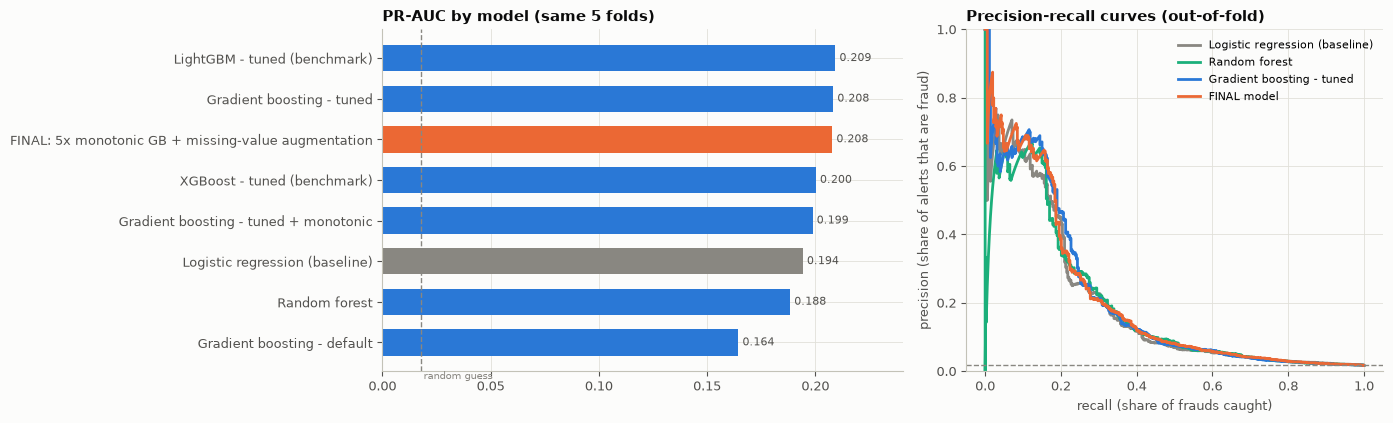

In [12]:
final_ensemble = VotingClassifier([(f'gb_seed{s}', hgb(seed=s, monotonic=True)) for s in range(5)], voting='soft')

t = time.time()
FOLD_MODELS = []
OOF_FINAL = cv_oof(final_ensemble, n_repeats=3, augment=True, keep_models=FOLD_MODELS)
elapsed = time.time() - t
OOF['FINAL: 5x monotonic GB + missing-value augmentation'] = OOF_FINAL[:1]
results.append(summarize('FINAL: 5x monotonic GB + missing-value augmentation', OOF_FINAL[:1], elapsed / 3))

ap_runs = [average_precision_score(y, o) for o in OOF_FINAL]
print(f'Final model over 3 CV repeats: PR-AUC {np.mean(ap_runs):.4f} +/- {np.std(ap_runs):.4f}  |  '
      f'ROC-AUC {np.mean([roc_auc_score(y, o) for o in OOF_FINAL]):.4f}')

table = pd.DataFrame(results).set_index('model')
table.insert(1, 'x random', table['PR-AUC'] / rate)
display(table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.3), gridspec_kw={'width_ratios': [1.25, 1]})
order = table.sort_values('PR-AUC')
colors = [ORANGE if n.startswith('FINAL') else (MUTED if 'baseline' in n else BLUE) for n in order.index]
axes[0].barh(order.index, order['PR-AUC'], color=colors, height=0.65)
axes[0].axvline(rate, ls='--', lw=1, color=MUTED)
axes[0].text(rate, -0.9, ' random guess', color=MUTED, fontsize=7.5)
for i, v in enumerate(order['PR-AUC']):
    axes[0].text(v, i, f' {v:.3f}', va='center', fontsize=8, color=INK2)
axes[0].set_title('PR-AUC by model (same 5 folds)', loc='left'); axes[0].set_xlim(0, order['PR-AUC'].max() * 1.15)
for (name, col) in [('Logistic regression (baseline)', MUTED), ('Random forest', AQUA), ('Gradient boosting - tuned', BLUE),
                    ('FINAL: 5x monotonic GB + missing-value augmentation', ORANGE)]:
    pr, rc, _ = precision_recall_curve(y, OOF[name][0])
    axes[1].plot(rc, pr, lw=2, color=col, label=name.replace(': 5x monotonic GB + missing-value augmentation', ' model'))
axes[1].axhline(rate, ls='--', lw=1, color=MUTED)
axes[1].set_xlabel('recall (share of frauds caught)'); axes[1].set_ylabel('precision (share of alerts that are fraud)')
axes[1].set_title('Precision-recall curves (out-of-fold)', loc='left'); axes[1].legend(fontsize=8); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

**Reading the comparison:**
- **Every model beats random by a wide margin** (about 10–12× on PR-AUC).
- **Boosting beats the baseline.** The tuned gradient-boosting family beats logistic regression and random forest by about 0.01–0.02 PR-AUC. The gap is small in absolute terms (the labels are noisy), but it held in every repeated experiment we ran, because boosting can model the interactions the EDA revealed.
- **Default boosting overfits.** With default settings (deeper, faster), gradient boosting does worse than the tuned version, confirming that this noisy problem rewards strong regularisation.
- **LightGBM / XGBoost score the same** as scikit-learn's gradient boosting, within noise. We keep scikit-learn, which means one fewer dependency in deployment.
- **The final model adds robustness without hurting accuracy.** On its own, the monotonic version loses a little PR-AUC on this split (within noise; about −0.004 on average in our repeated experiments). Bagging and missing-value augmentation win it back: the final model matches the best single model while being stabler (±0.003 across CV repeats) and safer on extreme or incomplete inputs.

## 9. Choosing the decision threshold

The model outputs a **fraud probability**. The bank needs a **yes/no decision**: block or challenge the transaction, or let it pass.
- **The default 0.5 cut-off is useless here:** it would flag almost nothing.
- **What the threshold controls:** every threshold trades **recall** (frauds caught) against **precision** (alerts that are real fraud, i.e. little disruption to good customers).

How we choose:
1. **Recall matters a bit more than precision.** A missed fraud loses money, while a false alarm usually costs one extra verification (an OTP or a call). We therefore maximise **F1.5**, an F-score that weights recall 1.5× more than precision.
2. **We use the average curve over 3 CV repeats**, so the choice is stable.

,F1-optimal threshold,F1.5-optimal threshold
CV repeat 1,0.2475,0.0675
CV repeat 2,0.3000,0.0975
CV repeat 3,0.1150,0.0950


Chosen threshold (F1.5-optimal on the averaged curve): 0.0950
Equivalent business rule: flag when P(fraud) > 0.095, i.e. treat a missed fraud as ~10x as costly as a false alarm


,% flagged,precision,recall,F1,F1.5,share of fraud $ caught
0.050,4.272,0.149,0.361,0.211,0.251,0.580
0.095,1.735,0.274,0.269,0.271,0.271,0.462
0.100,1.638,0.283,0.263,0.272,0.268,0.448
0.150,1.045,0.353,0.209,0.262,0.239,0.374
0.250,0.622,0.515,0.181,0.268,0.226,0.317


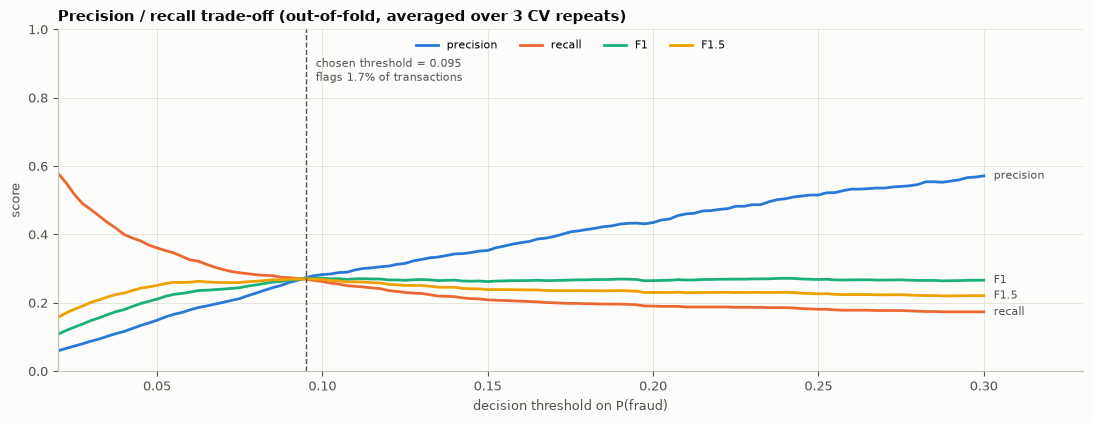

In [13]:
grid = np.round(np.arange(0.02, 0.3001, 0.0025), 4)
amount = train_df['transaction_amount'].values

def operating_point(t, oofs):
    rows = []
    for o in oofs:
        flag = (o >= t).astype(int)
        rows.append([100 * flag.mean(), precision_score(y, flag, zero_division=0), recall_score(y, flag),
                     f1_score(y, flag), fbeta_score(y, flag, beta=1.5),
                     amount[(flag == 1) & (y == 1)].sum() / amount[y == 1].sum()])
    return np.mean(rows, axis=0)

curve = pd.DataFrame([operating_point(t, OOF_FINAL) for t in grid], index=grid,
                     columns=['% flagged', 'precision', 'recall', 'F1', 'F1.5', 'share of fraud $ caught'])
THRESHOLD = float(curve['F1.5'].idxmax())
T_F1 = float(curve['F1'].idxmax())

stability = pd.DataFrame({
    'F1-optimal threshold': [grid[np.argmax([f1_score(y, (o >= t).astype(int)) for t in grid])] for o in OOF_FINAL],
    'F1.5-optimal threshold': [grid[np.argmax([fbeta_score(y, (o >= t).astype(int), beta=1.5) for t in grid])] for o in OOF_FINAL]},
    index=[f'CV repeat {i + 1}' for i in range(len(OOF_FINAL))])
display(stability)
print(f'Chosen threshold (F1.5-optimal on the averaged curve): {THRESHOLD:.4f}')
print(f'Equivalent business rule: flag when P(fraud) > {THRESHOLD:.3f}, i.e. treat a missed fraud as ~{(1 - THRESHOLD) / THRESHOLD:.0f}x as costly as a false alarm')
display(curve.loc[sorted({0.05, THRESHOLD, 0.15, T_F1, 0.25})].round(3))

fig, ax = plt.subplots(figsize=(11, 4.3))
for col, c in [('precision', BLUE), ('recall', ORANGE), ('F1', AQUA), ('F1.5', YELLOW)]:
    ax.plot(curve.index, curve[col], lw=2, color=c, label=col)
    ax.text(curve.index[-1] + 0.003, curve[col].iloc[-1], col, color=INK2, fontsize=8, va='center')
ax.axvline(THRESHOLD, color=INK2, lw=1, ls='--')
ax.text(THRESHOLD + 0.003, 0.92, f'chosen threshold = {THRESHOLD:.3f}\nflags {curve.loc[THRESHOLD, "% flagged"]:.1f}% of transactions',
        fontsize=8, color=INK2, va='top')
ax.set_xlabel('decision threshold on P(fraud)'); ax.set_ylabel('score'); ax.set_ylim(0, 1); ax.set_xlim(0.02, 0.33)
ax.set_title('Precision / recall trade-off (out-of-fold, averaged over 3 CV repeats)', loc='left'); ax.legend(ncol=4, fontsize=8, loc='upper center')
plt.tight_layout(); plt.show()

**Why this threshold:**
- **F1.5 gives a stable choice.** The F1-optimal threshold jumps around between CV repeats because the F1 curve is almost flat at its top. F1.5 gives a **stable** optimum.
- **It costs nothing in F1.** At this threshold F1 is essentially at its maximum (0.271 vs 0.272), so we get a stable, recall-leaning threshold for free.
- **It has a plain business meaning.** "Act when the fraud probability exceeds ~9.5%" is the same as saying that missing a fraud costs about **10× more** than challenging a good customer. That is a realistic assumption for a step-up check such as an OTP.
- **Disruption stays small.** Only about 1.7% of transactions are flagged. Those alerts contain about a quarter of all frauds and **close to half of all fraud dollars**, because large frauds are the easiest to spot.

## 10. Final evaluation (honest, out-of-fold)

,baseline (logistic regression),final model,"final model, std over CV repeats"
PR-AUC,0.194,0.206,0.003
ROC-AUC,0.769,0.771,0.003
precision,0.227,0.274,0.010
recall,0.303,0.269,0.009
F1,0.259,0.271,0.009
% transactions flagged,2.360,1.735,0.032
% of fraud $ caught,46.798,46.228,1.899


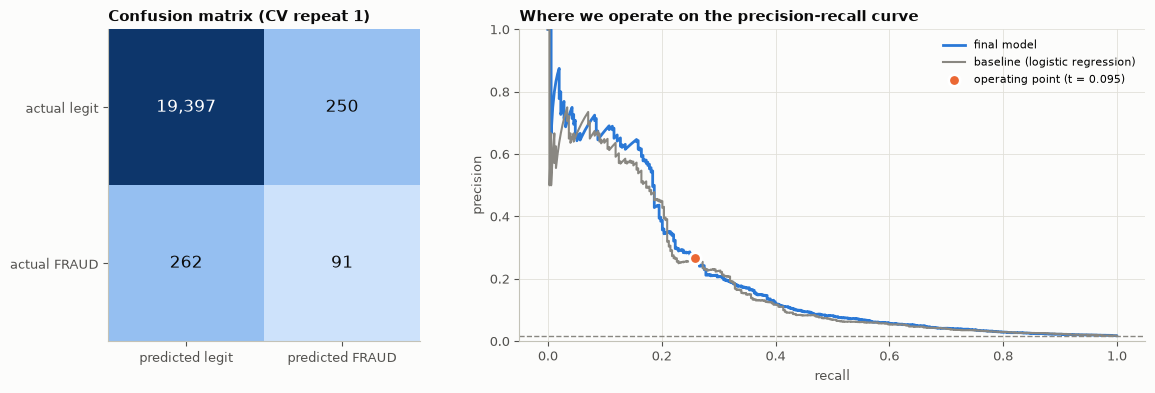

Out of 353 frauds we catch 91; we raise 341 alerts, of which 91 are real fraud (1 in 3.7).
Only 1.27% of legitimate customers are ever challenged.


In [14]:
def evaluate_at(oofs, t):
    rows = []
    for o in oofs:
        flag = (o >= t).astype(int)
        rows.append({'PR-AUC': average_precision_score(y, o), 'ROC-AUC': roc_auc_score(y, o),
                     'precision': precision_score(y, flag, zero_division=0), 'recall': recall_score(y, flag), 'F1': f1_score(y, flag),
                     '% transactions flagged': 100 * flag.mean(),
                     '% of fraud $ caught': 100 * amount[(flag == 1) & (y == 1)].sum() / amount[y == 1].sum()})
    return pd.DataFrame(rows)

base_oof = OOF['Logistic regression (baseline)']
base_t = best_threshold(y, base_oof[0], beta=1.5)   # baseline gets its own (optimistic) best threshold
final_eval = evaluate_at(OOF_FINAL, THRESHOLD)
report = pd.DataFrame({'baseline (logistic regression)': evaluate_at(base_oof, base_t).mean(),
                       'final model': final_eval.mean(), 'final model, std over CV repeats': final_eval.std(ddof=0)})
display(report.round(3))

cm = confusion_matrix(y, (OOF_FINAL[0] >= THRESHOLD).astype(int))
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [0.8, 1.2]})
axes[0].imshow(cm, cmap=SEQ, norm=plt.matplotlib.colors.LogNorm()); axes[0].grid(False)
for (i, j), v in np.ndenumerate(cm):
    axes[0].text(j, i, f'{v:,}', ha='center', va='center', fontsize=12, color='white' if v > 1000 else INK)
axes[0].set_xticks([0, 1], ['predicted legit', 'predicted FRAUD']); axes[0].set_yticks([0, 1], ['actual legit', 'actual FRAUD'])
axes[0].set_title('Confusion matrix (CV repeat 1)', loc='left')
pr, rc, th = precision_recall_curve(y, OOF_FINAL[0])
axes[1].plot(rc, pr, color=BLUE, lw=2, label='final model')
pb, rb, _ = precision_recall_curve(y, base_oof[0])
axes[1].plot(rb, pb, color=MUTED, lw=1.5, label='baseline (logistic regression)')
i = np.searchsorted(th, THRESHOLD)
axes[1].scatter([rc[i]], [pr[i]], s=70, color=ORANGE, zorder=5, edgecolor='white', linewidth=2, label=f'operating point (t = {THRESHOLD:.3f})')
axes[1].axhline(rate, ls='--', lw=1, color=MUTED)
axes[1].set_xlabel('recall'); axes[1].set_ylabel('precision'); axes[1].set_ylim(0, 1); axes[1].legend(fontsize=8)
axes[1].set_title('Where we operate on the precision-recall curve', loc='left')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Out of {tp + fn} frauds we catch {tp}; we raise {tp + fp} alerts, of which {tp} are real fraud (1 in {(tp + fp) / tp:.1f}).')
print(f'Only {fp / (fp + tn):.2%} of legitimate customers are ever challenged.')

## 11. Training the final model and explaining it

The final model is trained on **all 20,000 labelled transactions** plus their missing-value copy. The threshold is stored *inside* the model (`FixedThresholdClassifier`), so:
- `model.predict()` returns the 0/1 decision directly;
- `model.predict_proba()` still returns the risk score used for PR-AUC.

Final model trained on 40,000 rows in 17s | decision threshold = 0.0950


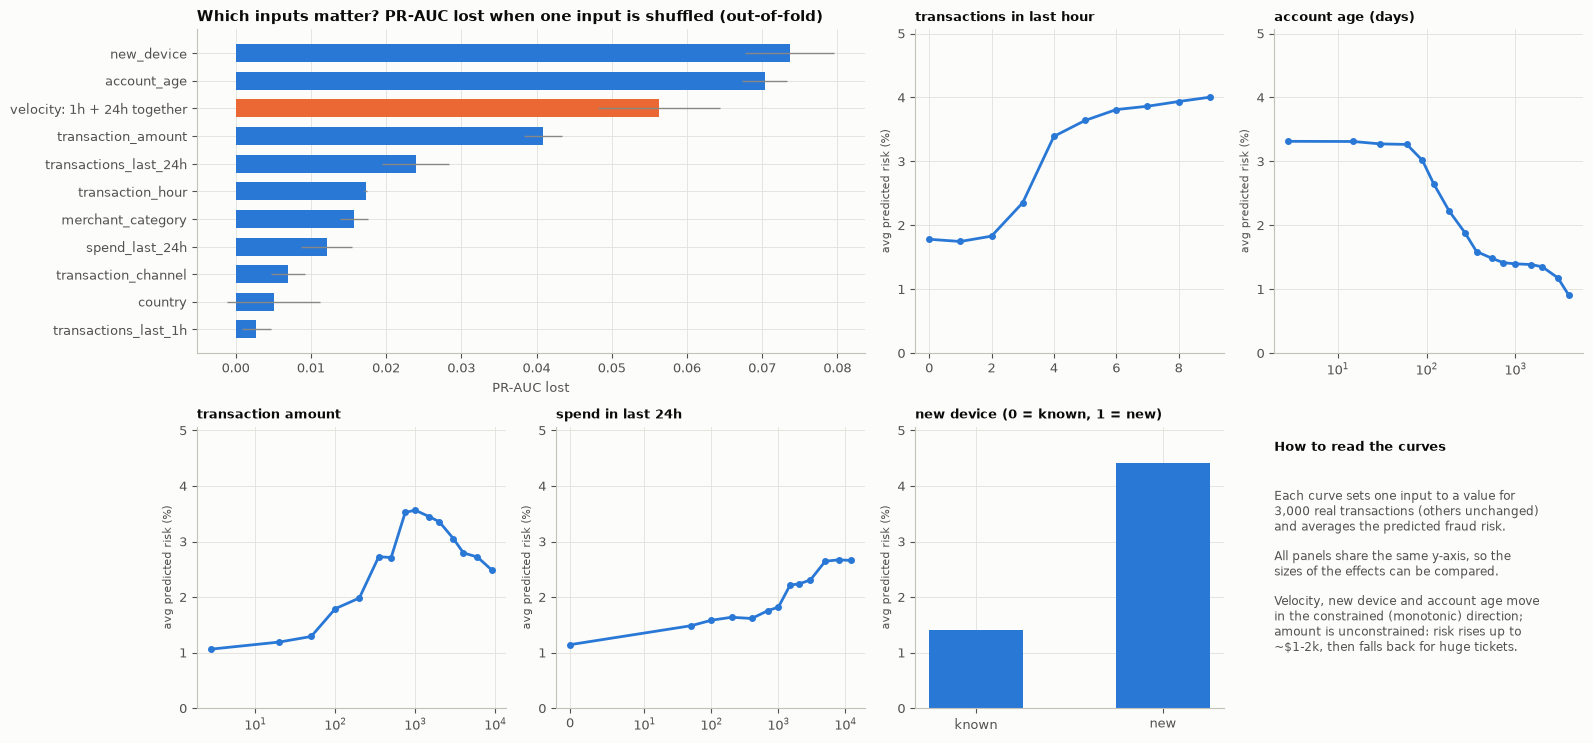

In [15]:
t = time.time()
train_aug = augment_with_missing(train_df, seed=2026)
final_model = FixedThresholdClassifier(final_ensemble, threshold=THRESHOLD, response_method='predict_proba')
final_model.fit(make_features(train_aug)[FEATURES], train_aug[TARGET].values)
print(f'Final model trained on {len(train_aug):,} rows in {time.time() - t:.0f}s | decision threshold = {THRESHOLD:.4f}')

# Which inputs matter? Out-of-fold permutation importance on RAW inputs: shuffle one input inside each validation
# fold (all derived features are recomputed), re-score with that fold's model, and measure the PR-AUC lost.
RAW_INPUTS = {c: [c] for c in RAW_NUM + CAT}
RAW_INPUTS['velocity: 1h + 24h together'] = ['transactions_last_1h', 'transactions_last_24h']
base_ap = average_precision_score(y, OOF_FINAL[0])
importance = {}
for name, cols in RAW_INPUTS.items():
    drops = []
    for rep in range(2):
        rng = np.random.default_rng(rep)
        p_perm = np.zeros(len(y))
        for val, fold_model in FOLD_MODELS:
            d = train_df.iloc[val].copy()
            order = rng.permutation(len(d))
            for c in cols:
                d[c] = d[c].values[order]
            p_perm[val] = fold_model.predict_proba(make_features(d)[FEATURES])[:, 1]
        drops.append(base_ap - average_precision_score(y, p_perm))
    importance[name] = (np.mean(drops), np.std(drops))
imp = pd.DataFrame(importance, index=['mean', 'std']).T.sort_values('mean')

# How does predicted risk respond to each key input? (all other inputs kept as observed)
sample = train_df.sample(3000, random_state=SEED)
def response(col, values):
    out = []
    for v in values:
        d = sample.copy(); d[col] = v
        if col == 'transactions_last_1h':
            d['transactions_last_24h'] = np.maximum(d['transactions_last_24h'], v)   # keep 1h <= 24h
        out.append(100 * final_model.predict_proba(make_features(d)[FEATURES])[:, 1].mean())
    return np.array(out)

fig = plt.figure(figsize=(16, 7.5))
gs = fig.add_gridspec(2, 4, height_ratios=[1.15, 1])
ax = fig.add_subplot(gs[0, :2])
ax.barh(imp.index, imp['mean'], xerr=imp['std'], color=[ORANGE if 'together' in i else BLUE for i in imp.index],
        height=0.65, error_kw={'ecolor': MUTED, 'lw': 1})
ax.set_title('Which inputs matter? PR-AUC lost when one input is shuffled (out-of-fold)', loc='left'); ax.set_xlabel('PR-AUC lost')
panels = [('transactions_last_1h', np.arange(0, 10), 'transactions in last hour'),
          ('account_age', np.array([5, 15, 30, 60, 90, 120, 180, 270, 365, 540, 730, 1000, 1500, 2000, 3000, 4000]), 'account age (days)'),
          ('transaction_amount', np.array([5, 20, 50, 100, 200, 350, 500, 750, 1000, 1500, 2000, 3000, 4000, 6000, 9000]), 'transaction amount'),
          ('spend_last_24h', np.array([0, 50, 100, 200, 400, 700, 1000, 1500, 2000, 3000, 5000, 8000, 12000]), 'spend in last 24h'),
          ('new_device', np.array([0, 1]), 'new device (0 = known, 1 = new)')]
positions = [gs[0, 2], gs[0, 3], gs[1, 0], gs[1, 1], gs[1, 2]]
curves = {col: response(col, vals) for col, vals, _ in panels}
top_y = 1.15 * max(c.max() for c in curves.values())
for (col, vals, label), pos in zip(panels, positions):
    a = fig.add_subplot(pos)
    r = curves[col]
    a.set_ylim(0, top_y)
    if col == 'new_device':
        a.bar(['known', 'new'], r, color=BLUE, width=0.5)
    else:
        a.plot(vals, r, color=BLUE, lw=2, marker='o', ms=4)
        if col in ('account_age', 'transaction_amount', 'spend_last_24h'):
            a.set_xscale('symlog', linthresh=10)
    a.set_title(label, loc='left', fontsize=9.5); a.set_ylabel('avg predicted risk (%)', fontsize=8)
a = fig.add_subplot(gs[1, 3]); a.axis('off')
a.text(0, 0.95, 'How to read the curves', fontweight='bold', color=INK, va='top')
a.text(0, 0.78, 'Each curve sets one input to a value for\n3,000 real transactions (others unchanged)\nand averages the predicted fraud risk.\n\n'
       'All panels share the same y-axis, so the\nsizes of the effects can be compared.\n\nVelocity, new device and account age move\nin the constrained (monotonic) direction;\n'
       'amount is unconstrained: risk rises up to\n~$1-2k, then falls back for huge tickets.', fontsize=8.5, color=INK2, va='top')
plt.tight_layout(); plt.show()

**What the model learned** (consistent with the EDA, a good sign that it is not memorising noise):
- **The four pillars of the score** are **new device**, **account age**, **velocity** and **amount**. Shuffling any one of them destroys 20–35% of the model's PR-AUC.
- **The two velocity fields are interchangeable.** On their own, `transactions_last_1h` and `transactions_last_24h` each look modest, because one substitutes for the other. Shuffled *together* (orange bar), they are among the most important inputs.
- **The response curves have the right shape.** Risk roughly triples with a new device, more than doubles from 3–4 transactions per hour, and falls steadily as the account ages.
- **Amount is non-linear:** risk rises up to about $1–2k and falls back for very large tickets. That is why we did **not** constrain it.
- **Context adds smaller nudges:** time of day, merchant category, spend in the last 24h and channel.

## 12. Robustness checks

In [16]:
# (a) Stress test: what happens when validation data has the test set's extra gaps?
stress = {}
for k, (trn, val) in enumerate(StratifiedKFold(5, shuffle=True, random_state=100).split(train_df, y)):
    X_clean = X.iloc[val][FEATURES]
    X_gappy = make_features(blank_fields(train_df.iloc[val], rate=0.03, seed=50 + k))[FEATURES]
    for name, aug in [('standard training', False), ('with missing-value augmentation', True)]:
        m = fit_on_raw(hgb(monotonic=True), train_df.iloc[trn], augment=aug, seed=k)
        stress.setdefault(name, {}).setdefault('clean validation', []).append(average_precision_score(y[val], m.predict_proba(X_clean)[:, 1]))
        stress[name].setdefault('validation with +3% gaps per field', []).append(average_precision_score(y[val], m.predict_proba(X_gappy)[:, 1]))
print('PR-AUC (mean of 5 folds), single monotonic GB model:')
display(pd.DataFrame({k: {kk: np.mean(vv) for kk, vv in v.items()} for k, v in stress.items()}).T.round(4))

# (b) What the model sees in the (shifted) test set
p_test = final_model.predict_proba(X_test[FEATURES])[:, 1]
flag_test = final_model.predict(X_test[FEATURES])
print(f'Test set: mean predicted fraud probability {p_test.mean():.2%} (train: {rate:.2%}) -> the test population looks riskier, as section 4 suggested')
print(f'Test set: {flag_test.mean():.2%} of transactions flagged (train out-of-fold: {curve.loc[THRESHOLD, "% flagged"]:.2f}%)')
vel = pd.cut(test_df['transactions_last_1h'], [-1, 2, 3, 4, 6, 9], labels=['0-2', '3', '4', '5-6', '7-9'])
print(pd.DataFrame({'test rows': vel.value_counts().sort_index(),
                    'avg predicted risk (%)': (100 * pd.Series(p_test, index=test_df.index).groupby(vel, observed=True).mean()).round(1),
                    'flagged (%)': (100 * pd.Series(flag_test, index=test_df.index).groupby(vel, observed=True).mean()).round(1)}).to_string())

PR-AUC (mean of 5 folds), single monotonic GB model:


,clean validation,validation with +3% gaps per field
standard training,0.2048,0.1981
with missing-value augmentation,0.2138,0.2068


Test set: mean predicted fraud probability 2.14% (train: 1.76%) -> the test population looks riskier, as section 4 suggested
Test set: 2.71% of transactions flagged (train out-of-fold: 1.74%)
                      test rows  avg predicted risk (%)  flagged (%)
transactions_last_1h                                                
0-2                       10915                     1.3          0.7
3                           315                     6.5         14.0
4                           106                    14.5         37.7
5-6                         190                    16.5         38.9
7-9                         229                    18.0         36.2


## 13. Save the model and predict (official submission format)

`model.pkl` contains `(model, feature_names)`, exactly as the upload instructions ask. To reproduce predictions in a fresh notebook:
1. Run the **feature-engineering cell** from section 5.
2. Run the **inference cell** below. It reads `DATATHON_INPUT_PATH` when that variable is set, which is how the hidden private test set is evaluated.

In [17]:
joblib.dump((final_model, FEATURES), 'model.pkl')
print(f'model.pkl saved ({os.path.getsize("model.pkl") / 1e6:.1f} MB)')

model.pkl saved (4.1 MB)


In [18]:
# ==== INFERENCE - same steps as the official upload instructions (needs the feature-engineering cell from section 5) ====
import os, joblib
import numpy as np
import pandas as pd

model, features = joblib.load('model.pkl')
default_test = TEST_PATH if 'TEST_PATH' in globals() else 'Track 2 Testing Dataset.csv'
input_path = os.environ.get('DATATHON_INPUT_PATH', default_test)
new_data = pd.read_csv(input_path)
X_new = make_features(new_data)
preds = model.predict(X_new[features]) if len(X_new) else np.array([], dtype=int)

output_file = 'The Larpers_Datathon 2026_Track 2_Prediction.csv'
pd.DataFrame({'prediction': preds}).to_csv(output_file, index=False)
print(f'Predictions saved successfully! {len(preds):,} rows -> {output_file} | flagged as fraud: {np.mean(preds):.2%}')

Predictions saved successfully! 12,000 rows -> The Larpers_Datathon 2026_Track 2_Prediction.csv | flagged as fraud: 2.71%


In [19]:
# Final checks: output format + the saved model survives messy, unseen inputs
out = pd.read_csv(output_file)
assert list(out.columns) == ['prediction'] and len(out) == len(new_data) and out['prediction'].isin([0, 1]).all()

messy = pd.DataFrame({
    'case': ['normal', 'negative / zero values', 'text in numeric fields', 'huge values', 'all missing', 'infinite values', 'unseen categories'],
    'transaction_amount': [50, -10, 'abc', 1e7, np.nan, np.inf, 25],
    'transaction_hour': [3, 25, -1, np.nan, None, '7', 12],
    'merchant_category': [' Retail', 'grocery', 'luxury', None, None, '', 'crypto'],
    'country': ['SG', 'xx', None, 'US', None, np.nan, 'Atlantis'],
    'transaction_channel': ['ecommerce', 'vr_headset', None, 'card_present', None, 'BANK_TRANSFER', 'atm'],
    'transactions_last_24h': [3, 0, -5, 1000, np.nan, '2', 4],
    'spend_last_24h': [100, -1, np.inf, 1e9, np.nan, 100, 50],
    'account_age': [10, 0, -3, 1e6, np.nan, 4000, np.inf],
    'new_device': [1, 0, 2, np.nan, np.nan, 'yes', 0],
    'transactions_last_1h': [9, 0, 50, np.nan, np.nan, -1, 3]})
m, feats = joblib.load('model.pkl')
messy_X = make_features(messy)[feats]
messy['P(fraud)'] = m.predict_proba(messy_X)[:, 1].round(3)
messy['decision'] = m.predict(messy_X)
assert messy['decision'].isin([0, 1]).all()
assert len(m.predict(make_features(messy.drop(columns=['country', 'spend_last_24h']))[feats])) == len(messy)   # missing columns
display(messy[['case', 'P(fraud)', 'decision']])
print('All checks passed: correct format, 0/1 outputs, robust to messy inputs and missing columns.')

,case,P(fraud),decision
0,normal,0.182,1
1,negative / zero values,0.013,0
2,text in numeric fields,0.127,1
3,huge values,0.051,0
4,all missing,0.013,0
5,infinite values,0.005,0
6,unseen categories,0.009,0


All checks passed: correct format, 0/1 outputs, robust to messy inputs and missing columns.


In [20]:
import importlib.metadata as md
packages = ['numpy', 'pandas', 'scikit-learn', 'joblib', 'matplotlib']
requirements = '\n'.join(f'{p}=={md.version(p)}' for p in packages) + '\n'
open('requirements.txt', 'w').write(requirements)
print(requirements)
print(f'Total notebook runtime: {(time.time() - T0) / 60:.1f} min')

numpy==2.1.3
pandas==2.2.3
scikit-learn==1.6.1
joblib==1.6.0
matplotlib==3.11.2

Total notebook runtime: 6.5 min


## 14. Assumptions, limitations and next steps

**Assumptions**

- **Transactions are independent.** There is no customer ID or timestamp, so we cannot build per-customer histories or validate in time order. Stratified CV is therefore the right tool.
- **Labels are correct and the behavioural fields are honest.** The `*_last_1h` and `*_last_24h` fields are assumed to be computed *before* the transaction, so they leak nothing.
- **Fraud patterns are stable** between train and the private test, even though the *mix* of customers shifts (covariate shift, section 4).

**Limitations**

- **The signal is noisy.** Even the riskiest segments are below 50% fraud, so precision is capped. The model is best used to **rank a review/step-up queue**, not to auto-block.
- **Some regions are thin in training data.** Behaviour above $4k or at 7+ transactions/hour is learnt from about 100–300 rows. The monotonic constraints make it safe, not certain.
- **The threshold rests on an assumed cost ratio (~10:1).** With real loss and friction costs, the bank should re-tune it. Our curve in section 9 makes that a one-line change.

**Next steps**

- **Use amount-aware costs:** flag when `P(fraud) × amount > review cost`. This catches more fraud dollars per alert.
- **Add the missing context:** customer IDs and timestamps would enable per-customer baselines and time-based validation; device and IP fingerprints would add new signals.
- **Monitor in production:** track drift (adversarial AUC, missing rates) and re-calibrate the threshold monthly. Collect analyst feedback on the alerts to grow the labelled data.